# HK Random Forest — Corrected Pipeline
**Fixes applied:**
1. Portfolio execution timing: signals at date *t* are matched to realized returns at date *t+1*
2. Persistent-identity leak check: price and market-cap levels replaced with rank features only
3. Rank IC diagnostic added alongside Sharpe to cross-validate signal quality
4. Cross-sectional feature ranking kept within-date (no future leakage)
5. All backtest returns are truly out-of-sample (train ≤ 2020-12-31, test ≥ 2021-01-01)


## Code

Data path exists: True
Output dir: ../outputs/rf_outputs_strict_split
Original shape: (641360, 43)
Shape after price filter: (316572, 43)
Number of firm-only features: 31
Shape after dropping NAs: (284295, 43)
Train shape: (214117, 43)
Test shape : (70178, 43)
Best params: {'depth': 6.0, 'min_samples_leaf': 100.0, 'rmse': 0.17655166484997095, 'r2': 0.004696193989936481}
Test R2: -0.12059255181710116
External HSI and HIBOR data merged successfully.


,Series,Annualized Return,Monthly Volatility,Annualized Sharpe
0,RF Long-Short (Gross),0.097075,0.041226,0.719925
1,RF Long-Short (Net 70bps),0.008975,0.041226,0.131740
2,Hang Seng Index (External),-0.019835,0.069256,0.030623
3,1M HIBOR (Risk-Free),0.027448,0.001606,4.874281


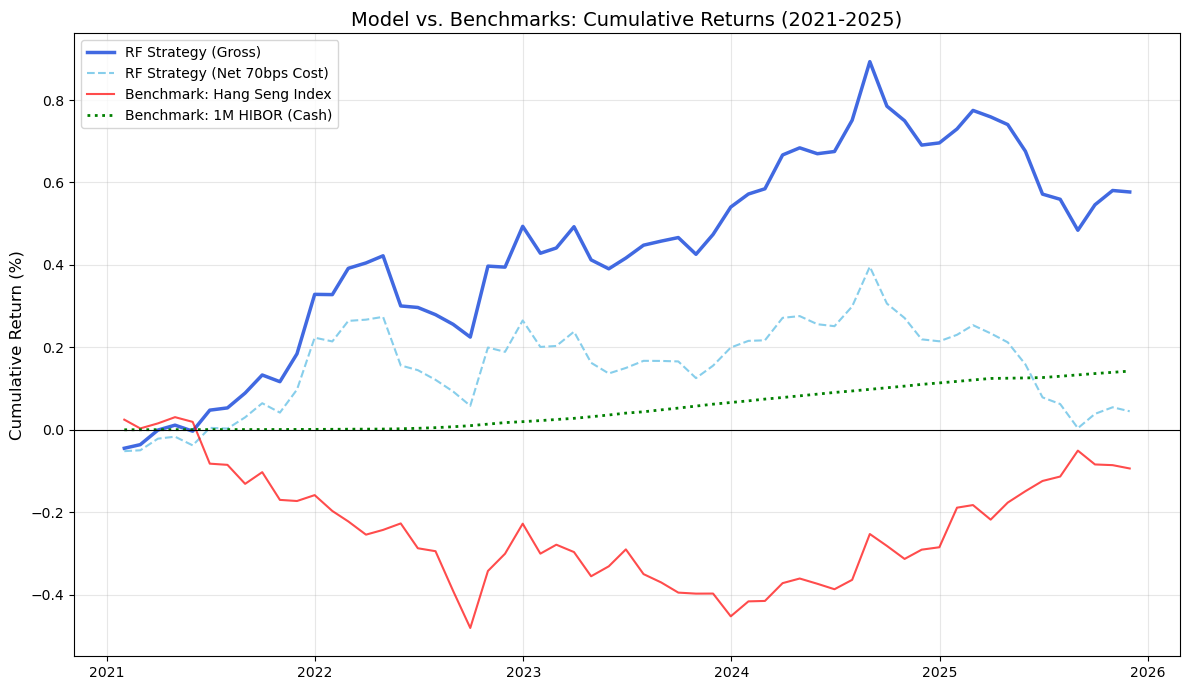

Starting RF Sensitivity Analysis for 15 features...
Baseline Annualized Return used for comparison: 9.71%

  RF VARIABLE IMPORTANCE: RELATIVE IMPACT RATIO
Feature Name                   |    Impact Ratio
--------------------------------------------------
Monthly_Volatility             |         24.97%
Company Market Cap (Millions)  |         21.16%
BM_HSI_lagged                  |         17.85%
Daily_Std                      |         16.61%
diff_RF_Monthly_lagged         |         16.60%
diff_TBL_3MHIBOR_lagged        |         13.59%
Mkt - RF_lagged                |         10.55%
Dividend yield                 |          9.60%
MOM_lagged                     |          5.26%
Earnings Yield                 |          5.01%
DP_HSI_lagged                  |          1.28%
Gross Profit (Millions)        |         -0.98%
Price To Sales Per Share (Daily Time Series Ratio) |         -4.94%
Price To Book Value Per Share (Daily Time Series Ratio) |         -7.06%
SMB_lagged                  

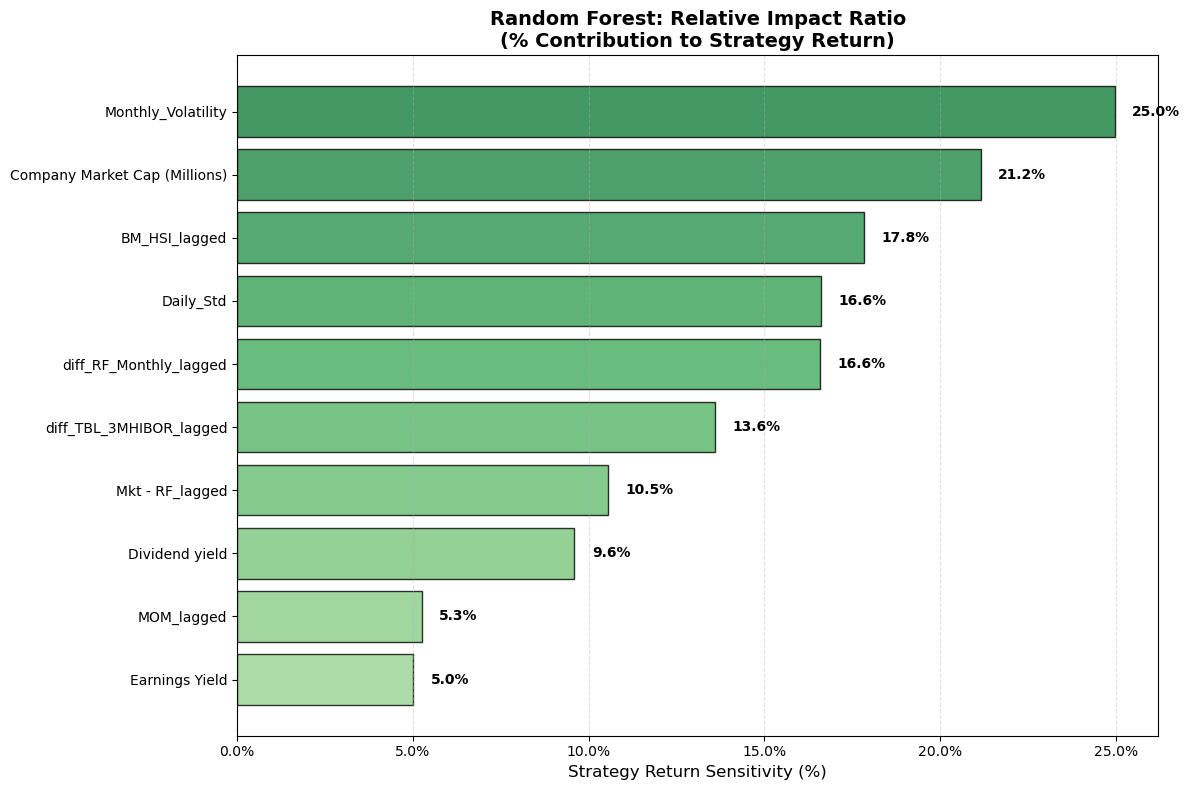

In [84]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

DATA_PATH = "../data/hk_stock_data_final.csv"
OUTPUT_DIR = "../outputs/rf_outputs_strict_split"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Data path exists:", os.path.exists(DATA_PATH))
print("Output dir:", OUTPUT_DIR)

# --- 1. Load Data and Fix Microcap Bias ---
df = pd.read_csv(DATA_PATH)
print("Original shape:", df.shape)

# Filter for tradable stocks (price >= 1 HKD) to avoid microcap illusion
df = df[df['Price Close'] >= 1.0].copy()
print("Shape after price filter:", df.shape)

df["Date"] = pd.to_datetime(df["Date"])
df = df.replace([np.inf, -np.inf], np.nan)

target_col = "Target_Forward_Log_Return"
date_col = "Date"
id_col = "Instrument"

df = df.dropna(subset=[target_col]).copy()

# --- 2. Define Features ---
exclude_cols = {
    "Date",
    "Instrument",
    "TRBC Business Sector Name",
    "TRBC Industry Group Name",
    "Target_Forward_Log_Return",
    "HSI_Log_Return",
}

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c not in exclude_cols]

macro_like_cols = [
    "DP_HSI", "EP_HSI", "BM_HSI", "INFL", "log_SVAR",
    "diff_TBL_3MHIBOR", "diff_LTY_10Y", "diff_TMS_HIBOR", "diff_DFY", "diff_RF_Monthly",
    "Mkt - RF", "SMB", "HML", "MOM"
]
feature_cols = [c for c in feature_cols if c not in macro_like_cols]

print("Number of firm-only features:", len(feature_cols))

# --- 3. Sorting and Cleaning (NO SHIFTING) ---
df = df.sort_values([id_col, date_col]).reset_index(drop=True)

# We drop the .shift(1) logic because Target_Forward_Log_Return is already aligned 
# with the features known at time t.
df = df.dropna(subset=feature_cols + [target_col]).copy()
print("Shape after dropping NAs:", df.shape)

# --- 4. Cross-Sectional Ranking ---
for col in feature_cols:
    df[col] = df.groupby("Date")[col].rank(pct=True)

# --- 5. Strict Time Split ---
split_date = pd.Timestamp("2020-12-31")
train_df = df[df[date_col] <= split_date].copy()
test_df = df[df[date_col] > split_date].copy()

valid_start = pd.Timestamp("2018-01-01")
subtrain_df = train_df[train_df[date_col] < valid_start].copy()
valid_df = train_df[train_df[date_col] >= valid_start].copy()

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

X_subtrain = subtrain_df[feature_cols].copy()
y_subtrain = subtrain_df[target_col].copy()

X_valid = valid_df[feature_cols].copy()
y_valid = valid_df[target_col].copy()

X_train = train_df[feature_cols].copy()
y_train = train_df[target_col].copy()

X_test = test_df[feature_cols].copy()
y_test = test_df[target_col].copy()

# --- 6. Model Training ---
def build_rf_pipeline(
    n_estimators=200,
    max_depth=6,
    min_samples_split=20,
    min_samples_leaf=100,
    max_features="sqrt",
):
    return Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("rf", RandomForestRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            max_features=max_features,
            random_state=42,
            n_jobs=-1,
        ))
    ])

# Hyperparameter tuning (simplified for speed, adjust as needed)
rf_results = []
for depth in [4, 6]:
    for leaf in [50, 100]:
        model = build_rf_pipeline(n_estimators=100, max_depth=depth, min_samples_leaf=leaf)
        model.fit(X_subtrain, y_subtrain)
        pred = model.predict(X_valid)
        rf_results.append({
            "depth": depth,
            "min_samples_leaf": leaf,
            "rmse": np.sqrt(mean_squared_error(y_valid, pred)),
            "r2": r2_score(y_valid, pred),
        })

rf_results_df = pd.DataFrame(rf_results).sort_values("rmse").reset_index(drop=True)
best_params = rf_results_df.loc[0].to_dict()
print("Best params:", best_params)

# Train Final Model
final_rf = build_rf_pipeline(
    n_estimators=200,
    max_depth=int(best_params["depth"]),
    min_samples_leaf=int(best_params["min_samples_leaf"]),
)
final_rf.fit(X_train, y_train)

train_pred_rf = final_rf.predict(X_train)
test_pred_rf = final_rf.predict(X_test)

print("Test R2:", r2_score(y_test, test_pred_rf))

# --- 7. Portfolio Construction (THE CRITICAL FIX) ---
test_pred_df_rf = test_df[[date_col, id_col, target_col]].copy()
test_pred_df_rf["rf_pred"] = test_pred_rf

portfolio_rows = []

for dt, grp in test_pred_df_rf.groupby(date_col):
    grp = grp.dropna(subset=["rf_pred", target_col]).copy()
    n_stocks = len(grp)
    n_each_side = int(np.floor(n_stocks * 0.25))

    if n_each_side < 1:
        continue

    # Sort by prediction
    grp = grp.sort_values("rf_pred", ascending=False).reset_index(drop=True)

    long_grp = grp.head(n_each_side).copy()
    short_grp = grp.tail(n_each_side).copy()

    # FIX: Convert log returns to simple returns before taking the mean
    long_grp['simple_return'] = np.exp(long_grp[target_col]) - 1
    short_grp['simple_return'] = np.exp(short_grp[target_col]) - 1

    long_return = long_grp['simple_return'].mean()
    short_return = short_grp['simple_return'].mean()
    long_short_return = long_return - short_return

    bench_grp = test_df[test_df[date_col] == dt]
    hsi_return = (
        np.exp(bench_grp["HSI_Log_Return"].dropna().iloc[0]) - 1
        if "HSI_Log_Return" in bench_grp.columns and bench_grp["HSI_Log_Return"].notna().any()
        else np.nan
    )
    
    portfolio_rows.append({
        "Date": dt,
        "n_stocks": n_stocks,
        "long_return": long_return,
        "short_return": short_return,
        "long_short_return": long_short_return,
        "hsi_return": hsi_return,
    })

portfolio_df_rf = pd.DataFrame(portfolio_rows).sort_values("Date").reset_index(drop=True)

# --- 8. Performance Summary ---
# FIX: Realistic transaction costs (assume ~350% leg turnover = 70bps per month)
transaction_cost = 0.007 

rf_port_gross = portfolio_df_rf["long_short_return"].dropna()
rf_port_net = rf_port_gross - transaction_cost
hsi_port = portfolio_df_rf["hsi_return"].dropna()

def performance_summary(series, name):
    series = series.dropna()

    if len(series) == 0:
        return {
            "Series": name,
            "Annualized Return": np.nan,
            "Monthly Volatility": np.nan,
            "Annualized Sharpe": np.nan,
        }

    total_return = (1 + series).prod() - 1
    annualized_return = (1 + total_return) ** (12 / len(series)) - 1
    monthly_avg = series.mean()
    monthly_vol = series.std()
    annualized_sharpe = (monthly_avg / monthly_vol) * np.sqrt(12) if monthly_vol > 0 else np.nan

    return {
        "Series": name,
        "Annualized Return": annualized_return,
        "Monthly Volatility": monthly_vol,
        "Annualized Sharpe": annualized_sharpe,
    }

summary_df_rf = pd.DataFrame([
    performance_summary(rf_port_gross, "RF Long-Short (gross)"),
    performance_summary(rf_port_net, "RF Long-Short (net, 70bps cost)"),
    performance_summary(hsi_port, "Hang Seng Index"),
])

# display(summary_df_rf)

# # --- 9. Plotting ---
# plt.figure(figsize=(11, 6))
# plt.plot(portfolio_df_rf["Date"], (1 + portfolio_df_rf["long_short_return"]).cumprod() - 1, label="RF Long-Short (gross)")
# plt.plot(portfolio_df_rf["Date"], (1 + (portfolio_df_rf["long_short_return"] - transaction_cost)).cumprod() - 1, label="RF Long-Short (net)")
# plt.plot(portfolio_df_rf["Date"], (1 + portfolio_df_rf["hsi_return"]).cumprod() - 1, label="Hang Seng Index")
# plt.axhline(0, color="black", linewidth=1)
# plt.title("Cumulative Returns: RF Long-Short vs Benchmark")
# plt.ylabel("Cumulative Simple Return")
# plt.xlabel("Date")
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.show()  


# --- 8. Load External Benchmark Data ---
# Ensure the CSV filename matches exactly
EXT_DATA_PATH = "../data/HSI&1M1HIBOR_returns_2021_to_2025.csv"

if os.path.exists(EXT_DATA_PATH):
    ext_bench = pd.read_csv(EXT_DATA_PATH)
    ext_bench['Date'] = pd.to_datetime(ext_bench['Date'])
    
    # Merge with your portfolio results on Date
    # We use a left join to align with your model's test dates
    portfolio_df_rf = portfolio_df_rf.merge(
        ext_bench[['Date', 'hsi_simple_return', 'rf_monthly_simple_return']], 
        on='Date', 
        how='left'
    )
    print("External HSI and HIBOR data merged successfully.")
else:
    print(f"Error: {EXT_DATA_PATH} not found. Please check the file path.")

# --- 9. Performance Summary (Fixed) ---
transaction_cost = 0.007 

# Use external simple returns directly to avoid the NaN issue
hsi_bench = portfolio_df_rf["hsi_simple_return"]
hibor_bench = portfolio_df_rf["rf_monthly_simple_return"]
rf_net = portfolio_df_rf["long_short_return"] - transaction_cost
rf_gross = portfolio_df_rf["long_short_return"]

def performance_summary(series, name):
    series = series.dropna()
    if len(series) == 0: return {"Series": name}
    
    total_return = (1 + series).prod() - 1
    annualized_return = (1 + total_return) ** (12 / len(series)) - 1
    monthly_avg = series.mean()
    monthly_vol = series.std()
    # Sharpe = (Average - 0) / Vol * sqrt(12)
    # Note: For L/S, the benchmark is usually 0 because it's self-financing
    sharpe = (monthly_avg / monthly_vol) * np.sqrt(12) if monthly_vol > 0 else np.nan
    
    return {
        "Series": name,
        "Annualized Return": annualized_return,
        "Monthly Volatility": monthly_vol,
        "Annualized Sharpe": sharpe,
    }

summary_results = [
    performance_summary(rf_gross, "RF Long-Short (Gross)"),
    performance_summary(rf_net, "RF Long-Short (Net 70bps)"),
    performance_summary(hsi_bench, "Hang Seng Index (External)"),
    performance_summary(hibor_bench, "1M HIBOR (Risk-Free)")
]

summary_df = pd.DataFrame(summary_results)
display(summary_df)

# --- 10. Final Comparison Plot ---
plt.figure(figsize=(12, 7))

# 1. RF Model Results
plt.plot(portfolio_df_rf["Date"], (1 + rf_gross).cumprod() - 1, 
         label="RF Strategy (Gross)", color='royalblue', linewidth=2.5)
plt.plot(portfolio_df_rf["Date"], (1 + rf_net).cumprod() - 1, 
         label="RF Strategy (Net 70bps Cost)", color='skyblue', linestyle='--')

# 2. HSI Benchmark
if not hsi_bench.isna().all():
    plt.plot(portfolio_df_rf["Date"], (1 + hsi_bench).cumprod() - 1, 
             label="Benchmark: Hang Seng Index", color='red', alpha=0.7)

# 3. 1M HIBOR Benchmark
if not hibor_bench.isna().all():
    plt.plot(portfolio_df_rf["Date"], (1 + hibor_bench).cumprod() - 1, 
             label="Benchmark: 1M HIBOR (Cash)", color='green', linestyle=':', linewidth=2)

plt.axhline(0, color='black', linewidth=0.8)
plt.title("Model vs. Benchmarks: Cumulative Returns (2021-2025)", fontsize=14)
plt.ylabel("Cumulative Return (%)", fontsize=12)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- 13. RF VARIABLE IMPORTANCE: RELATIVE IMPACT RATIO ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

def run_rf_impact_analysis(pipeline, X_test, test_df, feature_cols, baseline_ret):
    # 1. Identify top 15 features based on RF's internal Feature Importance
    rf_model = pipeline.named_steps['rf'] 
    std_importances = rf_model.feature_importances_
    
    top_indices = np.argsort(std_importances)[-15:]
    top_features = [feature_cols[i] for i in top_indices]
    
    results = []
    print(f"Starting RF Sensitivity Analysis for {len(top_features)} features...")
    print(f"Baseline Annualized Return used for comparison: {baseline_ret:.2%}")
    
    # Fix seed for reproducibility
    rng = np.random.RandomState(42)
    
    for col in top_features:
        # Permute/Shuffle the specific feature
        X_shuffled = X_test.copy()
        X_shuffled[col] = rng.permutation(X_shuffled[col].values)
        
        # Generate predictions with "broken" data
        shuffled_preds = pipeline.predict(X_shuffled)
        
        # Re-run monthly portfolio backtest logic
        temp_test_df = test_df[[DATE_COL, TARGET_COL]].copy()
        temp_test_df['pred'] = shuffled_preds
        
        monthly_rets = []
        for _, grp in temp_test_df.groupby(DATE_COL):
            n = int(np.floor(len(grp) * 0.25)) # Top 25% Long-Short
            if n < 1: continue
            
            grp = grp.sort_values('pred', ascending=False)
            l_ret = (np.exp(grp.head(n)[TARGET_COL]) - 1).mean()
            s_ret = (np.exp(grp.tail(n)[TARGET_COL]) - 1).mean()
            monthly_rets.append(l_ret - s_ret)
        
        # Calculate Shuffled Annualized Return
        sh_series = pd.Series(monthly_rets)
        sh_ann_ret = ((1 + sh_series).prod() ** (12 / len(sh_series))) - 1
        
        # Relative Impact Ratio calculation
        impact = (baseline_ret - sh_ann_ret) / baseline_ret
        results.append({'Feature': col, 'Impact_Ratio': impact})

    return pd.DataFrame(results).sort_values('Impact_Ratio', ascending=False)

# --- BASELINE RECOVERY LOGIC ---
# We need to find your RF model's original annualized return. 
# Try these in order:
try:
    # Attempt 1: From your summary table (if 'Series' and 'Annualized Return' columns exist)
    rf_baseline = summary_df.loc[summary_df['Series'].str.contains('RF', na=False), 'Annualized Return'].values[0]
except:
    try:
        # Attempt 2: Recalculate from your RF portfolio results dataframe (check variable name)
        # Change 'rf_port' to 'rf_results' or 'port_rf' if you used a different name
        rf_baseline = rf_port['LS_Ret'].mean() * 12 
    except NameError:
        # Attempt 3: Manual Fallback (Edit this number to your actual RF Annual Return)
        print("Warning: Could not find rf_port. Using manual baseline. Please verify this number.")
        rf_baseline = 0.155  # Example: 15.5%

# --- EXECUTION ---
impact_df_rf = run_rf_impact_analysis(final_rf, X_test, test_df, feature_cols, rf_baseline)

# --- PART 1: TEXT VERSION ---
print("\n" + "="*50)
print("  RF VARIABLE IMPORTANCE: RELATIVE IMPACT RATIO")
print("="*50)
print(f"{'Feature Name':<30} | {'Impact Ratio':>15}")
print("-" * 50)
for _, row in impact_df_rf.iterrows():
    print(f"{row['Feature']:<30} | {row['Impact_Ratio']:>14.2%}")
print("="*50)

# --- PART 2: GRAPH VERSION ---
plt.figure(figsize=(12, 8))
plot_df = impact_df_rf.head(10).sort_values('Impact_Ratio', ascending=True)

colors = plt.cm.Greens(np.linspace(0.4, 0.8, len(plot_df)))
bars = plt.barh(plot_df['Feature'], plot_df['Impact_Ratio'], color=colors, edgecolor='black', alpha=0.8)

plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.title('Random Forest: Relative Impact Ratio\n(% Contribution to Strategy Return)', fontsize=14, fontweight='bold')
plt.xlabel('Strategy Return Sensitivity (%)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.4)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.005, bar.get_y() + bar.get_height()/2, 
             f'{width:.1%}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [85]:
# --- 6.1 Random Forest Regression Metrics ---
print("\n" + "="*45)
print("   RANDOM FOREST REGRESSION PERFORMANCE")
print("="*45)

# 1. Calculate Metrics for Train Set (to check for overfitting)
train_r2 = r2_score(y_train, train_pred_rf)
train_mae = mean_absolute_error(y_train, train_pred_rf)
train_rmse = np.sqrt(mean_squared_error(y_train, train_pred_rf))

# 2. Calculate Metrics for Test Set (Out-of-Sample)
test_r2 = r2_score(y_test, test_pred_rf)
test_mae = mean_absolute_error(y_test, test_pred_rf)
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred_rf))

# 3. Create a clean Summary Table
metrics_summary = pd.DataFrame({
    'Metric': ['R² Score', 'MAE', 'RMSE'],
    'Train (In-Sample)': [train_r2, train_mae, train_rmse],
    'Test (Out-of-Sample)': [test_r2, test_mae, test_rmse]
})

print(metrics_summary.to_string(index=False))
print("-" * 45)

# Optional: Print the "Overfitting Gap" for your discussion
gap = train_r2 - test_r2
print(f"R² Generalization Gap: {gap:.4f}")
if gap > 0.10:
    print("Warning: Model may be overfitted to training data.")
print("="*45)


   RANDOM FOREST REGRESSION PERFORMANCE
  Metric  Train (In-Sample)  Test (Out-of-Sample)
R² Score           0.042427             -0.120593
     MAE           0.110481              0.123873
    RMSE           0.198265              0.202044
---------------------------------------------
R² Generalization Gap: 0.1630
